# Active Learning

Active Learning is a machine learning paradigm in which the learning algorithm
actively selects the most informative data points for labeling.

Instead of labeling the entire dataset, we assume that:

- a large amount of data is available without labels,
- obtaining labels is expensive,
- a labeling oracle (human expert, specialist, or external system) can provide labels,
- the model decides which examples should be labeled next.

The central objective is:

> Achieve strong predictive performance using as few labeled examples as possible.

This makes Active Learning especially useful when unlabeled data is abundant
but obtaining reliable labels is expensive.

## 1. Why Active Learning?

In conventional supervised learning, we generally assume that a labeled dataset
is already available:

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{n}
$$

The model learns a function

$$
f_\theta : X \rightarrow Y
$$

from the labeled dataset.

However, in many real-world problems, collecting the input data is relatively
easy while obtaining the correct labels is expensive.

Examples include:

- medical image diagnosis,
- fraud detection,
- scientific data annotation,
- document classification,
- speech recognition,
- satellite image interpretation,
- autonomous systems.

Suppose we have 100,000 unlabeled examples but can afford to label only 1,000.

Randomly selecting 1,000 examples may waste the labeling budget on examples
that the model already understands.

Active Learning instead asks:

$$
\text{Which unlabeled example should we label next?}
$$

The answer is determined by a **query strategy**.

## 2. Active Learning Setup

We divide the available data into two sets.

### Labeled set

$$
\mathcal{D}_L
=
\{(x_i,y_i)\}_{i=1}^{n_L}
$$

### Unlabeled pool

$$
\mathcal{D}_U
=
\{x_i\}_{i=1}^{n_U}
$$

Initially, the labeled set is usually small while the unlabeled pool is large.

The active learning process is:

$$
\mathcal{D}_L
\rightarrow
\text{Train model}
\rightarrow
\text{Query unlabeled examples}
\rightarrow
\text{Obtain labels}
\rightarrow
\text{Expand } \mathcal{D}_L
$$

This process is repeated until the labeling budget is exhausted or another
stopping criterion is reached.

## 3. Pool-Based Active Learning

In **pool-based active learning**, the learner has access to a large pool
of unlabeled examples.

At iteration $t$:

$$
\mathcal{D}_L^{(t)}
$$

contains the currently labeled examples and

$$
\mathcal{D}_U^{(t)}
$$

contains the remaining unlabeled examples.

The learner chooses a query:

$$
x^*
=
\arg\max_{x \in \mathcal{D}_U^{(t)}} A(x)
$$

where $A(x)$ is an **acquisition function** or **query function**.

The oracle provides the corresponding label:

$$
y^* = \mathcal{O}(x^*)
$$

The labeled set is then updated:

$$
\mathcal{D}_L^{(t+1)}
=
\mathcal{D}_L^{(t)}
\cup
\{(x^*,y^*)\}
$$

and the queried example is removed from the unlabeled pool:

$$
\mathcal{D}_U^{(t+1)}
=
\mathcal{D}_U^{(t)}
\setminus
\{x^*\}
$$

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

## 4. Create a Synthetic Classification Dataset

We use the two-moons dataset.

The nonlinear structure makes it useful for visualizing which observations
are selected by different active learning strategies.

In [17]:
X, y = make_moons(
    n_samples=3000,
    noise=0.20,
    random_state=42
)

X.shape, y.shape

((3000, 2), (3000,))

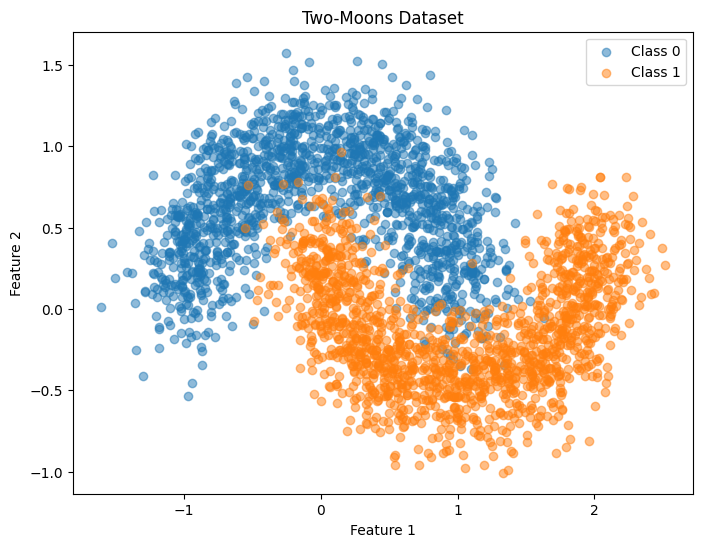

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    alpha=0.5,
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    alpha=0.5,
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Moons Dataset")
plt.legend()
plt.show()

## 5. Simulating the Labeling Oracle

In a real Active Learning system, the oracle may be:

- a medical expert,
- a human annotator,
- a domain specialist,
- an external labeling service.

For this experiment, the true synthetic labels act as our oracle.

Therefore, when the active learner requests the label of an example $x$,
we retrieve its known synthetic label.

This allows us to simulate the cost of querying labels while still having
ground-truth labels available for evaluation.

In [19]:
X_pool, X_test, y_pool, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

X_pool.shape, X_test.shape

((2250, 2), (750, 2))

The test set is kept completely separate.

It is **never queried** and is used only to evaluate the model.

The pool contains both:

- the initial labeled examples,
- the remaining unlabeled examples.

In [20]:
rng = np.random.default_rng(42)

initial_size = 20

initial_indices = rng.choice(
    len(X_pool),
    size=initial_size,
    replace=False
)

labeled_mask = np.zeros(len(X_pool), dtype=bool)
labeled_mask[initial_indices] = True

X_labeled = X_pool[labeled_mask]
y_labeled = y_pool[labeled_mask]

X_unlabeled = X_pool[~labeled_mask]

X_labeled.shape, X_unlabeled.shape

((20, 2), (2230, 2))

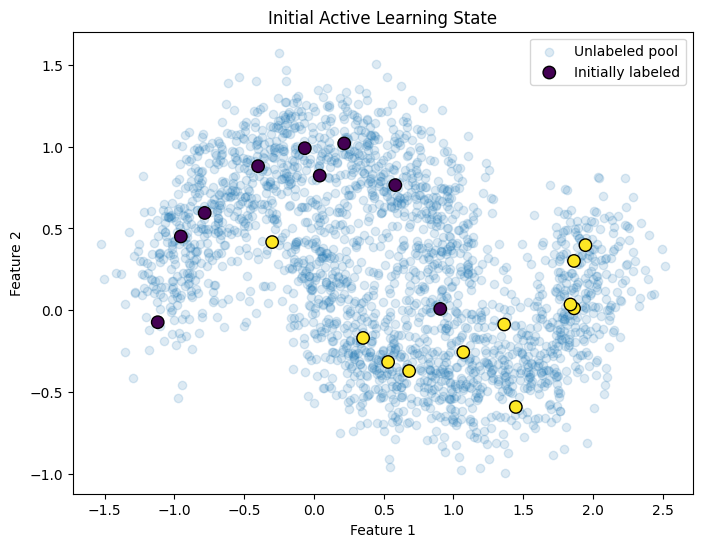

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unlabeled[:, 0],
    X_unlabeled[:, 1],
    alpha=0.15,
    label="Unlabeled pool"
)

plt.scatter(
    X_labeled[:, 0],
    X_labeled[:, 1],
    c=y_labeled,
    edgecolor="black",
    s=80,
    label="Initially labeled"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Initial Active Learning State")
plt.legend()
plt.show()

## 6. Random Sampling Baseline

Before implementing sophisticated query strategies, we need a baseline.

Random sampling selects examples uniformly from the unlabeled pool.

The query is:

$$
x^*
\sim
\text{Uniform}(\mathcal{D}_U)
$$

Random sampling is important because an active learning method should
demonstrate that intelligent querying provides an advantage over simply
spending the labeling budget randomly.

In [22]:
def random_query(X_unlabeled, n_queries, random_state=None):
    rng = np.random.default_rng(random_state)

    n_queries = min(n_queries, len(X_unlabeled))

    indices = rng.choice(
        len(X_unlabeled),
        size=n_queries,
        replace=False
    )

    return indices

## 7. Base Learner

We use Logistic Regression as the base classifier.

The goal of this notebook is to study **which examples should be labeled**,
not to optimize the classifier itself.

For a multiclass problem, a classifier estimates:

$$
P(y=k \mid x)
$$

For binary classification, this becomes:

$$
P(y=1 \mid x)
$$

These predicted probabilities will later be used to construct uncertainty
sampling strategies.

In [23]:
scaler = StandardScaler()

X_labeled_scaled = scaler.fit_transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_labeled_scaled,
    y_labeled
)

test_predictions = model.predict(X_test_scaled)

accuracy_score(y_test, test_predictions)

0.872

# 8. Uncertainty Sampling

The central idea of uncertainty sampling is simple:

> Ask the oracle to label examples about which the current model is least certain.

If a classifier is extremely confident:

$$
P(y=1\mid x) \approx 0
$$

or

$$
P(y=1\mid x) \approx 1
$$

then the example is usually not very informative.

However, if:

$$
P(y=1\mid x) \approx 0.5
$$

the classifier is uncertain.

Such examples are often close to the current decision boundary.

Therefore, uncertainty sampling focuses the labeling budget near regions
where the model needs more information.

## 9. Least Confidence Sampling

For a prediction distribution

$$
P(y=k\mid x)
$$

the confidence of the prediction is:

$$
\max_k P(y=k\mid x)
$$

Least Confidence uses:

$$
A_{\text{LC}}(x)
=
1 -
\max_k P(y=k\mid x)
$$

The learner selects:

$$
x^*
=
\arg\max_{x\in\mathcal{D}_U}
A_{\text{LC}}(x)
$$

For binary classification, examples with probabilities close to $0.5$
receive the highest uncertainty score.

In [25]:
def least_confidence_query(model, X_unlabeled, n_queries):
    probabilities = model.predict_proba(X_unlabeled)

    uncertainty = 1 - np.max(probabilities, axis=1)

    indices = np.argsort(uncertainty)[-n_queries:]

    return indices

## 10. Margin Sampling

Margin sampling considers the difference between the two most probable classes.

Let:

$$
p_1(x) \geq p_2(x) \geq \cdots
$$

The margin is:

$$
M(x)
=
p_1(x)-p_2(x)
$$

A small margin means that the model cannot clearly distinguish between
the leading classes.

Therefore, the acquisition score can be defined as:

$$
A_{\text{margin}}(x)
=
-
\left(
p_1(x)-p_2(x)
\right)
$$

The learner selects examples with the smallest margin.

In [26]:
def margin_query(model, X_unlabeled, n_queries):
    probabilities = model.predict_proba(X_unlabeled)

    sorted_probabilities = np.sort(
        probabilities,
        axis=1
    )

    margins = (
        sorted_probabilities[:, -1]
        - sorted_probabilities[:, -2]
    )

    indices = np.argsort(margins)[:n_queries]

    return indices

## 11. Entropy Sampling

Entropy measures uncertainty in a probability distribution.

For a classification problem:

$$
H(Y\mid x)
=
-\sum_{k=1}^{K}
P(y=k\mid x)
\log P(y=k\mid x)
$$

High entropy means that probability mass is distributed across several
possible classes.

Low entropy means that the model is confident about one class.

Therefore:

$$
x^*
=
\arg\max_{x\in\mathcal{D}_U}
H(Y\mid x)
$$

Entropy sampling is especially useful for multiclass classification because
it considers the entire predictive distribution.

In [27]:
def entropy_query(model, X_unlabeled, n_queries):
    probabilities = model.predict_proba(X_unlabeled)

    probabilities = np.clip(
        probabilities,
        1e-12,
        1.0
    )

    entropy = -np.sum(
        probabilities * np.log(probabilities),
        axis=1
    )

    indices = np.argsort(entropy)[-n_queries:]

    return indices

In [28]:
probabilities = model.predict_proba(X_unlabeled)

least_confidence = 1 - np.max(
    probabilities,
    axis=1
)

sorted_probabilities = np.sort(
    probabilities,
    axis=1
)

margins = (
    sorted_probabilities[:, -1]
    - sorted_probabilities[:, -2]
)

probabilities_clipped = np.clip(
    probabilities,
    1e-12,
    1.0
)

entropy = -np.sum(
    probabilities_clipped *
    np.log(probabilities_clipped),
    axis=1
)

uncertainty_df = pd.DataFrame({
    "least_confidence": least_confidence,
    "margin": margins,
    "entropy": entropy
})

uncertainty_df.head()

,least_confidence,margin,entropy
0,0.251423,0.497155,0.563893
1,0.305286,0.389429,0.615277
2,0.303507,0.392986,0.613807
3,0.062123,0.875755,0.232768
4,0.172536,0.654927,0.459885


## Visualize Queried Points

In [29]:
n_queries = 30

lc_indices = least_confidence_query(
    model,
    X_unlabeled_scaled,
    n_queries
)

margin_indices = margin_query(
    model,
    X_unlabeled_scaled,
    n_queries
)

entropy_indices = entropy_query(
    model,
    X_unlabeled_scaled,
    n_queries
)

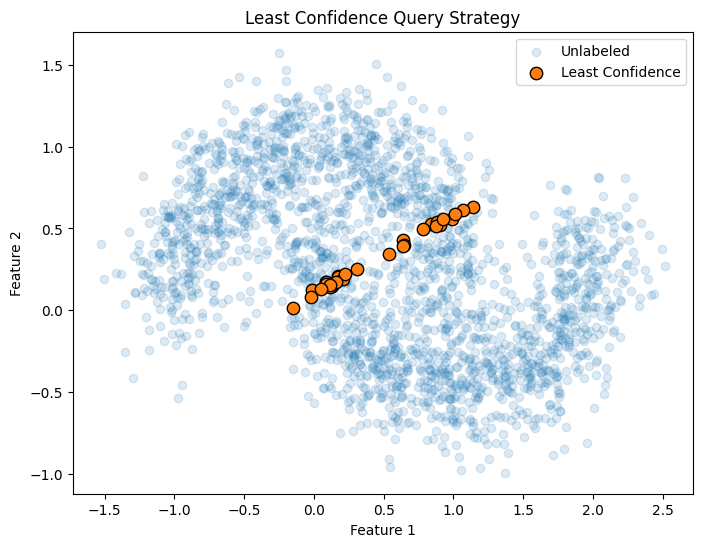

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unlabeled[:, 0],
    X_unlabeled[:, 1],
    alpha=0.15,
    label="Unlabeled"
)

plt.scatter(
    X_unlabeled[lc_indices, 0],
    X_unlabeled[lc_indices, 1],
    s=80,
    edgecolor="black",
    label="Least Confidence"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Least Confidence Query Strategy")
plt.legend()
plt.show()

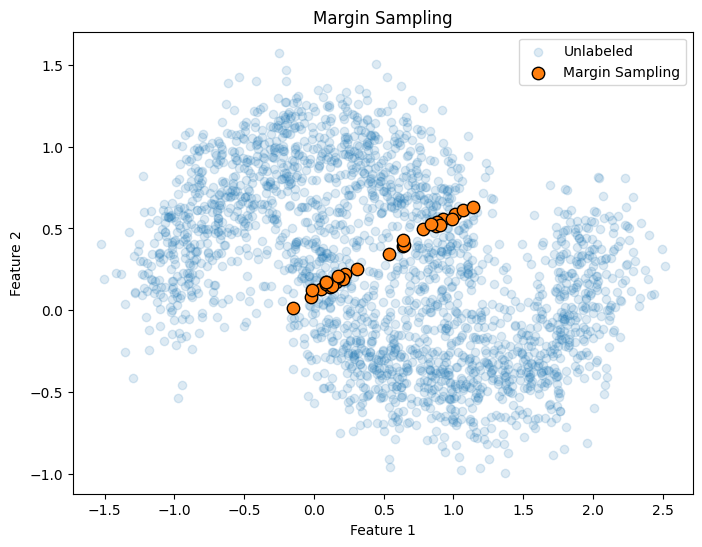

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unlabeled[:, 0],
    X_unlabeled[:, 1],
    alpha=0.15,
    label="Unlabeled"
)

plt.scatter(
    X_unlabeled[margin_indices, 0],
    X_unlabeled[margin_indices, 1],
    s=80,
    edgecolor="black",
    label="Margin Sampling"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Margin Sampling")
plt.legend()
plt.show()

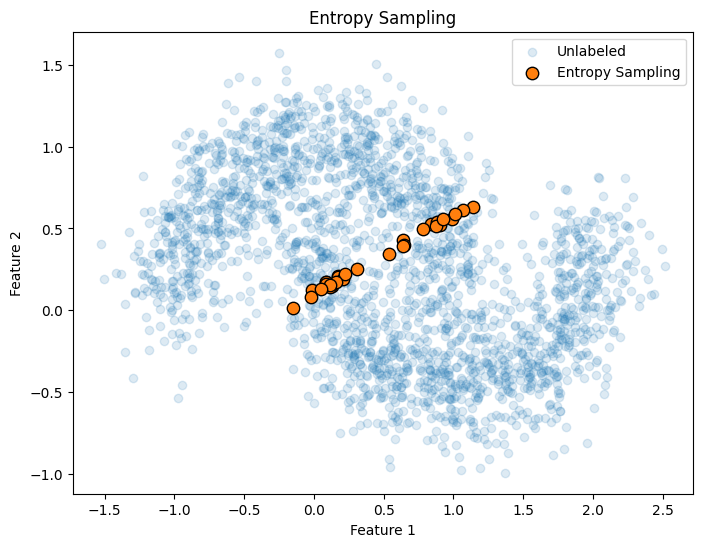

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unlabeled[:, 0],
    X_unlabeled[:, 1],
    alpha=0.15,
    label="Unlabeled"
)

plt.scatter(
    X_unlabeled[entropy_indices, 0],
    X_unlabeled[entropy_indices, 1],
    s=80,
    edgecolor="black",
    label="Entropy Sampling"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Entropy Sampling")
plt.legend()
plt.show()

## 12. Why Uncertainty Sampling Works

For many classifiers, uncertainty is concentrated near the decision boundary.

The model is confident in regions that are clearly associated with one class,
but becomes uncertain where classes overlap.

Consequently, uncertainty sampling tends to query points near the current
decision boundary.

This can be interpreted geometrically as:

$$
\text{Query informative boundary regions}
\rightarrow
\text{Improve decision boundary}
\rightarrow
\text{Improve generalization}
$$

# 13. The Active Learning Loop

A complete pool-based active learning algorithm can be expressed as:

1. Start with a small labeled dataset.
2. Train the model.
3. Evaluate the model on a separate test set.
4. Calculate an acquisition score for every unlabeled example.
5. Select the most informative examples.
6. Query their labels.
7. Add them to the labeled dataset.
8. Remove them from the unlabeled pool.
9. Repeat.

Mathematically:

$$
\theta^{(t)}
=
\operatorname{Train}
\left(
\mathcal{D}_L^{(t)}
\right)
$$

Then:

$$
Q^{(t)}
=
\operatorname{Query}
\left(
\mathcal{D}_U^{(t)},
\theta^{(t)}
\right)
$$

The oracle provides:

$$
Y_Q
=
\mathcal{O}(Q^{(t)})
$$

and the labeled dataset becomes:

$$
\mathcal{D}_L^{(t+1)}
=
\mathcal{D}_L^{(t)}
\cup
(Q^{(t)},Y_Q)
$$

## Generic Active Learning Function

In [33]:
def run_active_learning(
    X_pool,
    y_pool,
    X_test,
    y_test,
    query_strategy,
    initial_size=20,
    query_size=20,
    iterations=15,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    initial_indices = rng.choice(
        len(X_pool),
        size=initial_size,
        replace=False
    )

    labeled_indices = list(initial_indices)

    unlabeled_indices = [
        i for i in range(len(X_pool))
        if i not in set(initial_indices)
    ]

    history = []

    for iteration in range(iterations):

        X_labeled = X_pool[labeled_indices]
        y_labeled = y_pool[labeled_indices]

        scaler = StandardScaler()

        X_labeled_scaled = scaler.fit_transform(X_labeled)
        X_test_scaled = scaler.transform(X_test)
        X_unlabeled_scaled = scaler.transform(
            X_pool[unlabeled_indices]
        )

        model = LogisticRegression(
            max_iter=1000,
            random_state=42
        )

        model.fit(
            X_labeled_scaled,
            y_labeled
        )

        predictions = model.predict(X_test_scaled)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        f1 = f1_score(
            y_test,
            predictions
        )

        history.append({
            "iteration": iteration,
            "labeled_samples": len(labeled_indices),
            "accuracy": accuracy,
            "f1": f1
        })

        if len(unlabeled_indices) == 0:
            break

        current_query_size = min(
            query_size,
            len(unlabeled_indices)
        )

        selected_local_indices = query_strategy(
            model,
            X_unlabeled_scaled,
            current_query_size
        )

        selected_global_indices = [
            unlabeled_indices[i]
            for i in selected_local_indices
        ]

        labeled_indices.extend(
            selected_global_indices
        )

        selected_set = set(
            selected_global_indices
        )

        unlabeled_indices = [
            i for i in unlabeled_indices
            if i not in selected_set
        ]

    return pd.DataFrame(history)

## Random Baseline Function

In [34]:
def random_strategy(model, X_unlabeled, n_queries):
    rng = np.random.default_rng()

    return rng.choice(
        len(X_unlabeled),
        size=min(n_queries, len(X_unlabeled)),
        replace=False
    )

## Run Experiments

In [35]:
random_history = run_active_learning(
    X_pool,
    y_pool,
    X_test,
    y_test,
    query_strategy=random_strategy,
    initial_size=20,
    query_size=20,
    iterations=15,
    random_state=42
)

lc_history = run_active_learning(
    X_pool,
    y_pool,
    X_test,
    y_test,
    query_strategy=least_confidence_query,
    initial_size=20,
    query_size=20,
    iterations=15,
    random_state=42
)

margin_history = run_active_learning(
    X_pool,
    y_pool,
    X_test,
    y_test,
    query_strategy=margin_query,
    initial_size=20,
    query_size=20,
    iterations=15,
    random_state=42
)

entropy_history = run_active_learning(
    X_pool,
    y_pool,
    X_test,
    y_test,
    query_strategy=entropy_query,
    initial_size=20,
    query_size=20,
    iterations=15,
    random_state=42
)

## Compare Accuracy

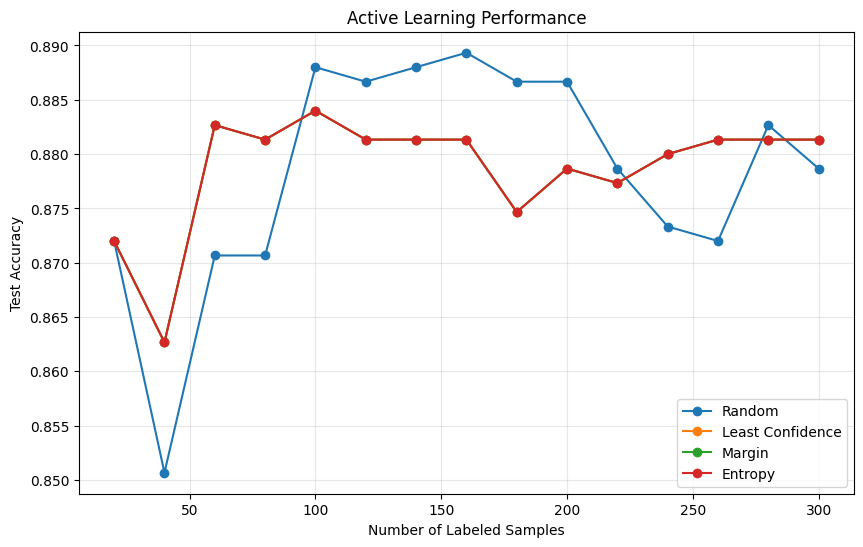

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    random_history["labeled_samples"],
    random_history["accuracy"],
    marker="o",
    label="Random"
)

plt.plot(
    lc_history["labeled_samples"],
    lc_history["accuracy"],
    marker="o",
    label="Least Confidence"
)

plt.plot(
    margin_history["labeled_samples"],
    margin_history["accuracy"],
    marker="o",
    label="Margin"
)

plt.plot(
    entropy_history["labeled_samples"],
    entropy_history["accuracy"],
    marker="o",
    label="Entropy"
)

plt.xlabel("Number of Labeled Samples")
plt.ylabel("Test Accuracy")
plt.title("Active Learning Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Compare F1 Score

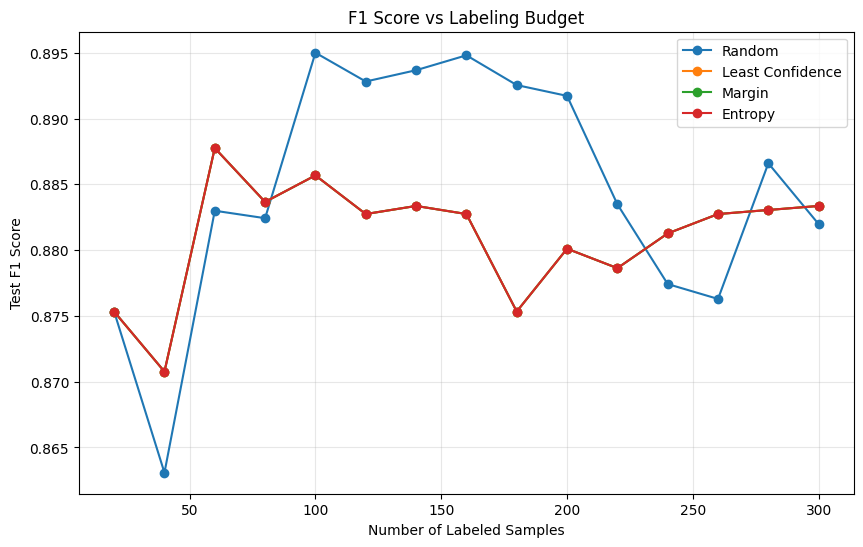

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    random_history["labeled_samples"],
    random_history["f1"],
    marker="o",
    label="Random"
)

plt.plot(
    lc_history["labeled_samples"],
    lc_history["f1"],
    marker="o",
    label="Least Confidence"
)

plt.plot(
    margin_history["labeled_samples"],
    margin_history["f1"],
    marker="o",
    label="Margin"
)

plt.plot(
    entropy_history["labeled_samples"],
    entropy_history["f1"],
    marker="o",
    label="Entropy"
)

plt.xlabel("Number of Labeled Samples")
plt.ylabel("Test F1 Score")
plt.title("F1 Score vs Labeling Budget")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 14. Labeling Efficiency

The most important question in Active Learning is not simply:

> Which method achieves the highest final accuracy?

Instead, we ask:

> How much performance can we obtain for a given labeling budget?

This creates a **labeling-efficiency curve**.

For example, suppose:

- Random sampling requires 500 labeled examples to achieve 90% accuracy.
- Active learning requires only 200.

Then Active Learning has achieved the same performance with:

$$
\frac{500-200}{500}
\times 100
=
60\%
$$

fewer labeled examples.

This reduction in annotation cost is the primary motivation for Active Learning.

# 15. Query-by-Committee

Uncertainty sampling relies on the uncertainty of a single model.

**Query-by-Committee (QBC)** instead maintains a committee of models:

$$
\mathcal{C}
=
\{f_1,f_2,\ldots,f_M\}
$$

Each model predicts the label of an unlabeled example.

If the committee strongly disagrees, the example may be informative.

For example:

$$
f_1(x)=0
$$

$$
f_2(x)=1
$$

$$
f_3(x)=0
$$

$$
f_4(x)=1
$$

The committee is uncertain about the correct label.

The learner therefore queries examples with high disagreement.

A simple disagreement measure is vote entropy:

$$
VE(x)
=
-\sum_{k=1}^{K}
\frac{V_k(x)}{M}
\log
\frac{V_k(x)}{M}
$$

where $V_k(x)$ is the number of committee members voting for class $k$.

## Committee Implementation

In [38]:
from sklearn.base import clone


def query_by_committee(
    X_labeled,
    y_labeled,
    X_unlabeled,
    n_queries,
    random_state=42
):
    committee = [
        LogisticRegression(
            C=0.1,
            max_iter=1000,
            random_state=random_state
        ),
        LogisticRegression(
            C=1.0,
            max_iter=1000,
            random_state=random_state
        ),
        LogisticRegression(
            C=10.0,
            max_iter=1000,
            random_state=random_state
        )
    ]

    predictions = []

    for model in committee:
        model.fit(X_labeled, y_labeled)
        predictions.append(
            model.predict(X_unlabeled)
        )

    predictions = np.array(predictions)

    disagreement = np.mean(
        predictions != predictions[0],
        axis=0
    )

    return np.argsort(disagreement)[-n_queries:]

# 16. Diversity in Active Learning

Uncertainty alone can select many similar examples.

Consider an unlabeled pool where thousands of examples lie close to the same
decision boundary.

Selecting all of them may provide redundant information.

A strong Active Learning system therefore considers two complementary goals:

### Uncertainty

Select examples the model does not understand.

### Diversity

Select examples that provide different information from one another.

This leads to the general principle:

$$
\text{Good queries}
\approx
\text{Uncertainty}
+
\text{Diversity}
$$

The exact combination depends on the acquisition strategy.

## 17. Core-Set Selection

Core-set methods try to select a representative subset of the data.

The intuition is:

> Choose a small set of examples that represents the unlabeled dataset well.

One formulation seeks a labeled subset whose coverage minimizes the distance
from every data point to its nearest selected point:

$$
\min_{S}
\max_{x\in\mathcal{D}}
\min_{s\in S}
d(x,s)
$$

where $d(x,s)$ is a distance function.

Core-set methods are useful when uncertainty sampling alone produces
redundant queries.

# 18. Active Learning and Label Noise

Active Learning assumes that queried labels are useful.

However, real-world oracles may make mistakes.

For example:

- human annotators may disagree,
- medical diagnoses may be ambiguous,
- images may be low quality,
- some classes may be inherently difficult to distinguish.

This creates a danger:

> An uncertainty-based learner may repeatedly query ambiguous or noisy
> examples.

Therefore, practical Active Learning systems may incorporate:

- multiple annotators,
- confidence estimates,
- label verification,
- disagreement resolution,
- noisy-label models,
- stopping rules.

Active Learning does not automatically solve the label-quality problem.
It only improves how the labeling budget is allocated.

# 19. When Should Active Learning Stop?

Possible stopping criteria include:

### Fixed labeling budget

Stop after a predetermined number of queries.

$$
|\mathcal{D}_L| \geq B
$$

where $B$ is the labeling budget.

### Performance threshold

Stop when:

$$
\text{Performance} \geq \tau
$$

for a desired threshold $\tau$.

### Small performance improvement

Stop when adding additional labels produces only a small improvement:

$$
\Delta M_t
=
M_t-M_{t-1}
<
\epsilon
$$

### Pool exhaustion

Stop when:

$$
|\mathcal{D}_U|=0
$$

# 20. Active Learning vs Passive Learning

| Property | Passive Learning | Active Learning |
|---|---|---|
| Data selection | Random/predefined | Model-selected |
| Label budget | Often large | Explicitly optimized |
| Unlabeled pool | Not essential | Usually important |
| Query strategy | None | Required |
| Main objective | Learn from available labels | Maximize information per label |
| Annotation cost | Potentially high | Potentially lower |
| Complexity | Lower | Higher |
| Risk | Wasted labels | Query bias / noisy labels |

The key distinction is:

$$ \boxed{ \text{Passive: labels are given} } $$

versus

Active: the learner chooses what to label
	​



---


# 21. Active Learning vs Semi-Supervised Learning

These two approaches both exploit unlabeled data, but they solve different
problems.

### Semi-Supervised Learning

The learner tries to make use of unlabeled examples without necessarily
requesting new labels.

Typical approaches include:

- pseudo-labeling,
- consistency regularization,
- graph-based methods,
- label propagation.

### Active Learning

The learner explicitly chooses which unlabeled examples should receive labels.

Therefore:

$$
\boxed{
\text{Semi-Supervised Learning}
\rightarrow
\text{Learn from unlabeled data}
}
$$

$$
\boxed{
\text{Active Learning}
\rightarrow
\text{Choose which data should be labeled}
}
$$

The two approaches can also be combined.

# 22. Applications

Active Learning is particularly valuable when annotation is expensive.

### Medical Imaging

Experts label a small number of difficult scans.

### Fraud Detection

Analysts investigate suspicious transactions selected by the model.

### Natural Language Processing

Human annotators label the most informative documents.

### Computer Vision

Experts annotate images that are uncertain or representative.

### Scientific Machine Learning

Researchers label expensive experimental observations.

### Autonomous Systems

Rare and difficult scenarios can be prioritized for annotation.

The common pattern is:

$$
\text{Large unlabeled dataset}
+
\text{expensive labels}
\rightarrow
\text{Active Learning}
$$

## Final Conceptual Workflow

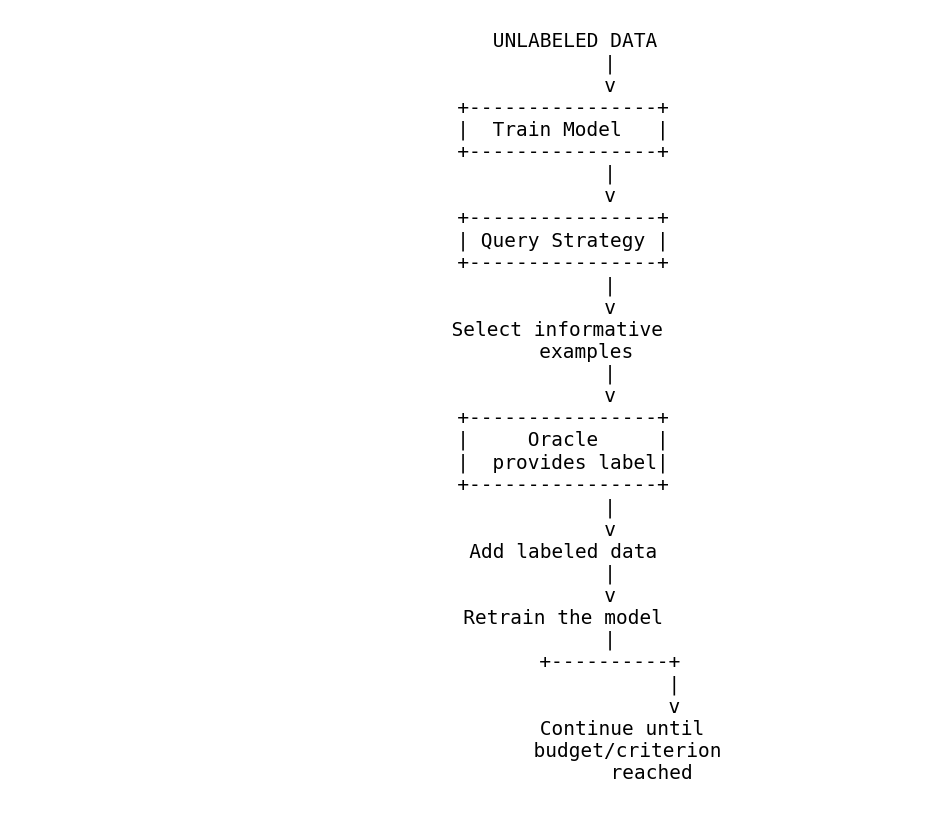

In [39]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axis("off")

workflow = """
                 UNLABELED DATA
                       |
                       v
               +----------------+
               |  Train Model   |
               +----------------+
                       |
                       v
               +----------------+
               | Query Strategy |
               +----------------+
                       |
                       v
              Select informative
                   examples
                       |
                       v
               +----------------+
               |     Oracle     |
               |  provides label|
               +----------------+
                       |
                       v
               Add labeled data
                       |
                       v
               Retrain the model
                       |
                       +----------+
                                  |
                                  v
                         Continue until
                          budget/criterion
                              reached
"""

ax.text(
    0.5,
    0.5,
    workflow,
    ha="center",
    va="center",
    fontsize=14,
    family="monospace"
)

plt.show()

# 23. Key Takeaways

1. Active Learning allows the model to decide which examples should be labeled.

2. The main goal is to maximize model performance under a limited labeling
   budget.

3. Pool-based Active Learning maintains:

$$
\mathcal{D}_L
\quad\text{and}\quad
\mathcal{D}_U
$$

4. Query strategies determine which examples are selected.

5. Uncertainty sampling focuses on examples where the model is uncertain.

6. Least Confidence uses:

$$
1-\max_k P(y=k\mid x)
$$

7. Margin sampling focuses on small differences between the top two class
   probabilities.

8. Entropy sampling measures uncertainty over the complete predictive
   distribution.

9. Query-by-Committee uses disagreement between multiple models.

10. Diversity can prevent redundant queries.

11. Label noise can reduce the effectiveness of Active Learning.

12. Active Learning should be evaluated against a passive/random baseline.

13. The most important evaluation question is often:

$$
\text{Performance}
\quad\text{vs}\quad
\text{Number of Labels}
$$

rather than performance alone.

14. Active Learning and Semi-Supervised Learning are related but distinct.

15. Active Learning is most valuable when:

$$
\boxed{
\text{Unlabeled data is abundant}
\quad+\quad
\text{labels are expensive}
}
$$

# 24. Final Summary

Active Learning changes the traditional supervised learning workflow.

Instead of asking:

> How can we train the best model from the labels we already have?

we ask:

> Which labels should we obtain next to improve the model most efficiently?

This introduces a decision-making component into the data collection process.

The fundamental loop is:

$$
\boxed{
\text{Train}
\rightarrow
\text{Query}
\rightarrow
\text{Label}
\rightarrow
\text{Update}
\rightarrow
\text{Repeat}
}
$$

The quality of an Active Learning system therefore depends on both:

$$
\boxed{
\text{Model quality}
+
\text{Query strategy}
}
$$

A strong Active Learning system does not simply find uncertain examples.
It should ultimately select examples that provide useful, diverse, and
reliable information under the available labeling budget.